In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')


In [2]:
import ast

def transform_to_dict(unique_array):

    result_dict = {'0': 'Null'}

    for item in unique_array:
        if item != '0':  
            variable_list = ast.literal_eval(item)
            
            for var in variable_list:
                # Diviser en numéro et nom, puis ajouter au dictionnaire
                num, name = map(str.strip, var.split(':'))
                result_dict[num] = name
    
    return result_dict


In [3]:
def count_common_Motifs(df1, df2):
   
    common_counts = []

    unique_Supports = set(df1['Support']).intersection(set(df2['Support']))

    for Support in unique_Supports:
        compteur = 0
        Motifs1 = df1[df1['Support'] == Support]['Motifs'].iloc[0] 
        Motifs2 = df2[df2['Support'] == Support]['Motifs'].iloc[0]  # Liste d'ensembles

        for motif_2 in Motifs2:
            for motif_1 in Motifs1:
                if motif_2 == motif_1:
                    compteur  = compteur + 1
        
        common_counts.append({'Support': Support, 'Pattern': compteur})
    return common_counts


In [4]:
def transform_column(df_column, variable_mapping):

    col_transform = []

    for x in df_column:
        t = x.strip("[]")
        a = t.split("}, {")
        
        result = [
            set(item.strip("{}").replace("'", "").split(", ")) for item in a
        ]
        
        transformed_line = []  
        for group in result:
            new_group = set()  
            for element in group:
                numero = ''.join(filter(str.isdigit, element))
                mapped_element = variable_mapping.get(numero, numero) + (element[-1] if not numero == element else "")
                new_group.add(mapped_element)
            transformed_line.append(new_group)  

        col_transform.append(transformed_line)

    return col_transform


In [5]:
def plot_number_pattern(df, file_name ):

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df,
        x="Support",
        y="Size",
        hue="Dataset",
        markers=True, 
        style="Dataset", 
        linewidth=2,  
        markersize=10,  
    )

    plt.ylabel('Number of patterns')
    plt.xlabel('Minimum support threshold')

    plt.tight_layout()
    plt.savefig("../data/article/"+file_name+".eps")
    plt.savefig("../data/article/"+file_name+".jpeg")
    plt.show()
    plt.close()


In [6]:
def plot_time(df, file_name ):

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df,
        x="Support",
        y="Temps d'exécution (s)",
        hue="Dataset",
        markers=True, 
        style="Dataset", 
        linewidth=2,  
        markersize=10,  
    )

    plt.ylabel("Time (s)")
    plt.xlabel('Minimum support threshold')

    plt.tight_layout()
    plt.savefig("../data/article/"+file_name+".eps")
    plt.savefig("../data/article/"+file_name+".jpeg")
    plt.show()
    plt.close()


In [7]:
def plot_memory(df, file_name ):

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df,
        x="Support",
        y="Mémoire maximale (Ko)",
        hue="Dataset",
        markers=True, 
        style="Dataset", 
        linewidth=2,  
        markersize=10,  
    )

    plt.ylabel("Memory usage(Ko)")
    plt.xlabel('Minimum support threshold')

    plt.tight_layout()
    plt.savefig("../data/article/"+file_name+".eps")
    plt.savefig("../data/article/"+file_name+".jpeg")
    plt.show()
    plt.close()


## Traitement du premier Dataset HCV

In [8]:
hcv = pd.read_excel("../data/serveur/HCV.xlsx")
hcv_pca = pd.read_excel("../data/serveur/HCV_PCA.xlsx")

In [9]:
df_hcv = pd.concat([hcv, hcv_pca], axis=0)  

In [10]:
df_hcv.shape

(39, 8)

In [11]:
df_hcv["Dataset"] = np.where(df_hcv["Dataset"] == './data/AfterPCA/HCV.csv','PCA HCV', 'HCV')

In [12]:
hcv["Motifs"] = transform_column(hcv["Motifs detectés"], transform_to_dict(hcv['Titre variables'].unique()))
hcv_pca["Motifs"] = transform_column(hcv_pca["Motifs detectés"], transform_to_dict(hcv_pca['Titre variables'].unique()))

In [13]:
hcv_valid = pd.DataFrame(count_common_Motifs(hcv, hcv_pca)).sort_values('Support')


In [14]:
hcv["Size"]

0     4716
1     2216
2     1525
3      813
4      589
5      496
6      272
7      176
8      150
9      120
10      94
11      94
12      48
13       7
14       0
15       7
16       0
17       0
18       0
19       0
Name: Size, dtype: int64

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


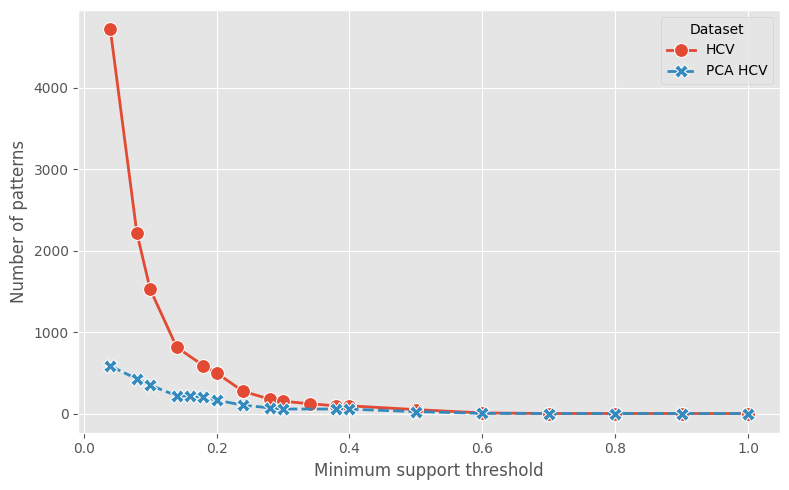

In [15]:
plot_number_pattern(df_hcv, "HCV_support_vs_Nb_patters")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


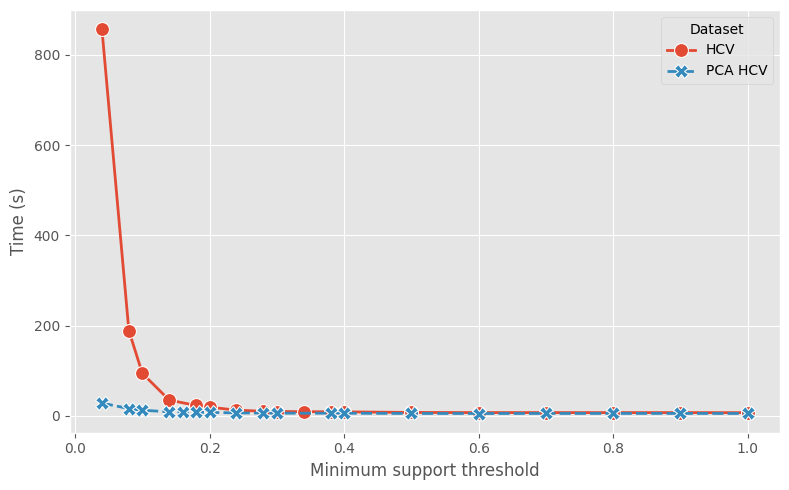

In [16]:
plot_time(df_hcv,"HCV_Time_vs_support" )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


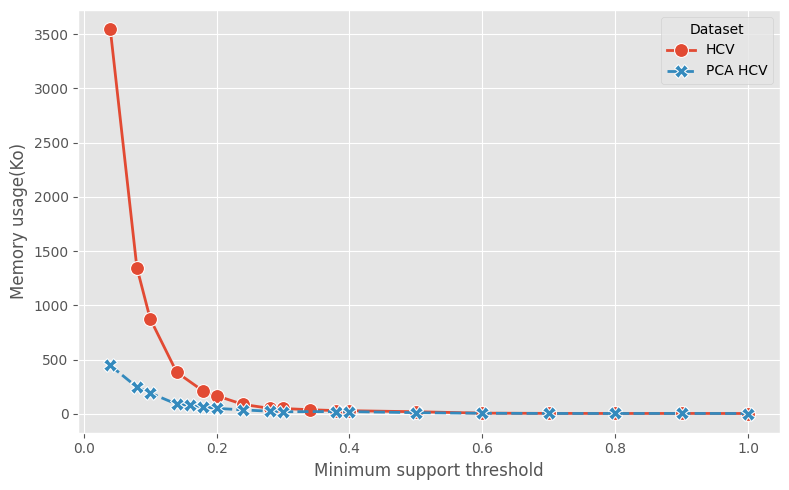

In [17]:
plot_memory(df_hcv, "HCV_Memory")

In [46]:
valid_all_df = pd.DataFrame()

In [47]:
valid_all_df

""


In [48]:
valid_all_df["Support"] = hcv["Support"]

In [53]:
valid_all_df["Size HCV"] = hcv["Size"]

In [50]:
valid_all_df["Size PCA HCV"] = hcv_pca["Size"]

In [51]:
valid_all_df["HCV common"] = hcv_valid["Pattern"]

In [59]:
hcv_valid.reset_index(drop=True, inplace=True)

In [61]:
hcv_valid

,Support,Pattern
0,0.04,75
1,0.08,218
2,0.10,231
3,0.14,170
4,0.18,159
5,0.20,138
6,0.24,83
7,0.28,59
8,0.30,49
9,0.38,44


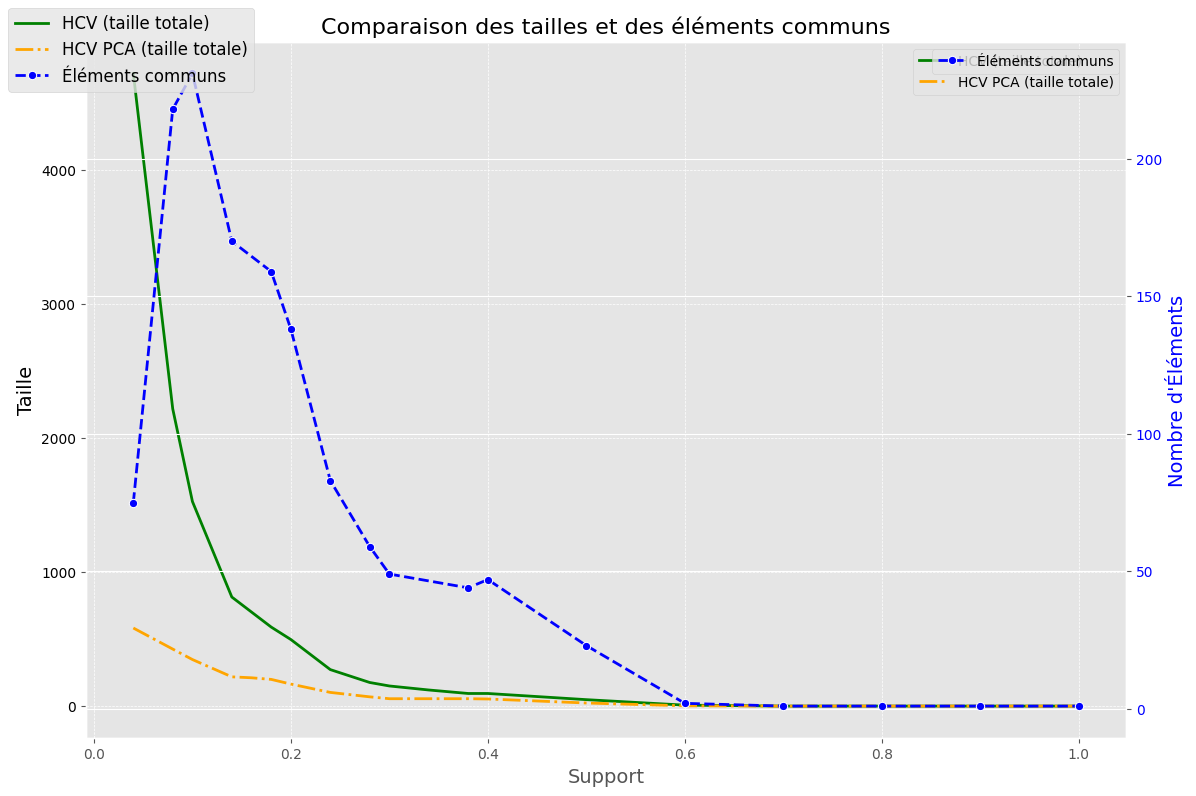

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

# Initialisation de la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# Premier axe (gauche) pour "Size" des courbes
sns.lineplot(data=hcv, x="Support", y="Size", label="HCV (taille totale)", color="green", linestyle="-", linewidth=2, ax=ax1)
sns.lineplot(data=hcv_pca, x="Support", y="Size", label="HCV PCA (taille totale)", color="orange", linestyle="-.", linewidth=2, ax=ax1)

# Configurer le premier axe (gauche)
ax1.set_xlabel("Support", fontsize=14)
ax1.set_ylabel("Taille", fontsize=14, color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_title("Comparaison des tailles et des éléments communs", fontsize=16)

# Deuxième axe (droite) pour "Pattern" des éléments communs
ax2 = ax1.twinx()
sns.lineplot(data=hcv_valid, x="Support", y="Pattern", label="Éléments communs", color="blue", linestyle="--", linewidth=2, ax=ax2, marker="o")

# Configurer le deuxième axe (droite)
ax2.set_ylabel("Nombre d'Éléments", fontsize=14, color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# Ajouter la légende (fusion des deux axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=12)

# Ajouter une grille pour plus de lisibilité
ax1.grid(True, which="both", linestyle="--", linewidth=0.5)

# Afficher le graphique
plt.tight_layout()
plt.show()


# Traitement de Air quality dataset

In [25]:
air = pd.read_excel("../data/serveur/Air Quality.xlsx")
air_pca = pd.read_excel("../data/serveur/Air Quality_PCA.xlsx")

In [26]:
df_air = pd.concat([air, air_pca], axis=0)  
df_air["Dataset"] = np.where(df_air["Dataset"] == './data/Clean/AirQualityUCI.csv','Air Quality','PCA Air Quailty')
air["Motifs"] = transform_column(air["Motifs detectés"], transform_to_dict(air['Titre variables'].unique()))
air_pca["Motifs"] = transform_column(air_pca["Motifs detectés"], transform_to_dict(air_pca['Titre variables'].unique()))
air_valid = pd.DataFrame(count_common_Motifs(air, air_pca)).sort_values('Support')


In [27]:
air_valid

,Support,Pattern
0,0.08,14
3,0.10,13
1,0.14,6
2,0.18,4
4,0.20,7
5,0.24,11
6,0.28,11
7,0.30,10
8,0.34,9
9,0.38,7


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


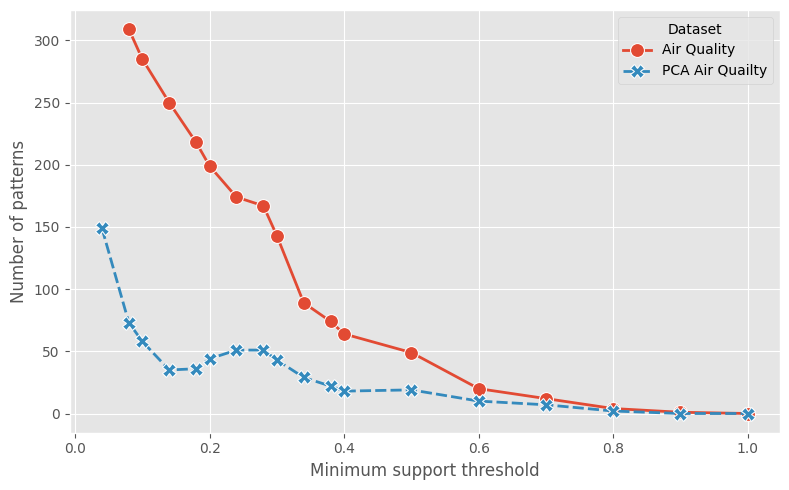

In [28]:
plot_number_pattern(df_air, "AIR_support_vs_Nb_patters")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


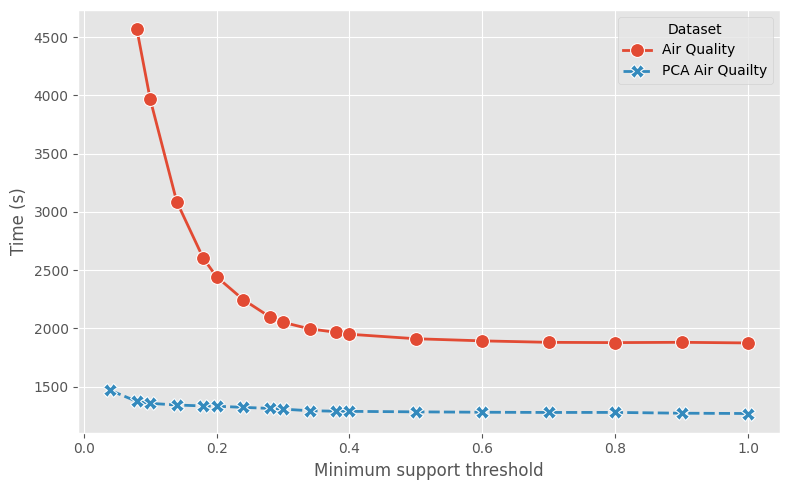

In [29]:
plot_time(df_air,"AIR_Time_vs_support" )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


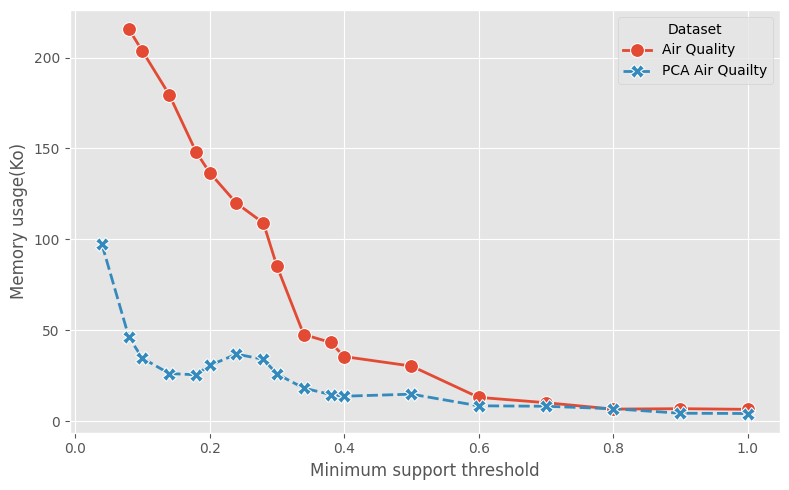

In [30]:
plot_memory(df_air,"AIR_memory_vs_support" )

<Axes: xlabel='Support', ylabel='Pattern'>

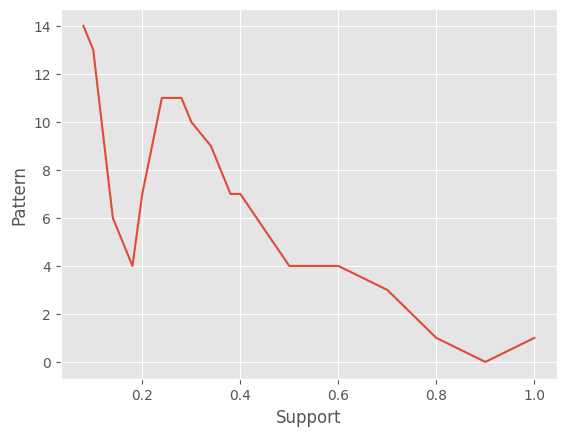

In [31]:
sns.lineplot(data=air_valid, x="Support", y="Pattern")

# Traitement du dataset cargo

In [32]:
cargo = pd.read_excel("../data/serveur/Cargo.xlsx")
cargo_pca = pd.read_excel("../data/serveur/Cargo_PCA.xlsx")

In [33]:
cargo

,Dataset,Support,Size,Temps d'exécution (s),Mémoire maximale (Ko),Titre variables,Supports motifs,Motifs detectés
0,./data/Clean/Cargo_2000.csv,0.18,15112,53440.722686,5448.187500,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.21062073498872447, 0.21545343280665308, 0.2...","[{'1+', '12+'}, {'1+', '12-'}, {'36+', '1+'}, ..."
1,./data/Clean/Cargo_2000.csv,0.20,11807,21149.035465,3798.742188,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.21062073498872447, 0.21545343280665308, 0.2...","[{'1+', '12+'}, {'1+', '12-'}, {'36+', '1+'}, ..."
2,./data/Clean/Cargo_2000.csv,0.24,3624,2457.997721,1128.652344,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.42399144355396334, 0.4450517018462711, 0.44...","[{'1+', '4-'}, {'1+', '13+'}, {'1+', '13-'}, {..."
3,./data/Clean/Cargo_2000.csv,0.28,1319,1501.517700,381.625000,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.4207548401324406, 0.42399144355396334, 0.44...","[{'1+', '4+'}, {'1+', '4-'}, {'1+', '6+'}, {'1..."
4,./data/Clean/Cargo_2000.csv,0.30,1039,1428.413661,286.031250,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.4207548401324406, 0.42399144355396334, 0.44...","[{'1+', '4+'}, {'1+', '4-'}, {'1+', '6+'}, {'1..."
5,./data/Clean/Cargo_2000.csv,0.34,803,1342.672671,224.070312,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.4207548401324406, 0.42399144355396334, 0.44...","[{'1+', '4+'}, {'1+', '4-'}, {'1+', '6+'}, {'1..."
6,./data/Clean/Cargo_2000.csv,0.38,815,1254.269561,219.554688,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.4207548401324406, 0.42399144355396334, 0.50...","[{'1+', '4+'}, {'1+', '4-'}, {'5+', '1+'}, {'1..."
7,./data/Clean/Cargo_2000.csv,0.40,775,1196.395916,209.210938,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.4207548401324406, 0.42399144355396334, 0.50...","[{'1+', '4+'}, {'1+', '4-'}, {'5+', '1+'}, {'1..."
8,./data/Clean/Cargo_2000.csv,0.50,119,956.629695,40.681641,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.5057330274002213, 0.5083164139345555, 0.504...","[{'1+', '2+'}, {'3+', '1+'}, {'5+', '1+'}, {'1..."
9,./data/Clean/Cargo_2000.csv,0.60,16,946.657938,13.483398,"['1 : i1_legid', '2 : i1_rcs_p', '3 : i1_rcs_e...","[0.8293391708316645, 0.7045439769836958, 0.643...","[{'3+', '2+'}, {'5+', '2+'}, {'7+', '2+'}, {'2..."


In [34]:
df_cargo = pd.concat([cargo, cargo_pca], axis=0)  
df_cargo["Dataset"] = np.where(df_cargo["Dataset"] == './data/Clean/Cargo_2000.csv','Cargo 2000','PCA Cargo 2000')
cargo["Motifs"] = transform_column(cargo["Motifs detectés"], transform_to_dict(cargo['Titre variables'].unique()))
cargo_pca["Motifs"] = transform_column(cargo_pca["Motifs detectés"], transform_to_dict(cargo_pca['Titre variables'].unique()))
cargo_valid = pd.DataFrame(count_common_Motifs(cargo, cargo_pca)).sort_values('Support')


In [35]:
cargo_valid

,Support,Pattern
0,0.18,161
3,0.20,165
1,0.24,715
2,0.28,467
4,0.30,413
5,0.34,387
6,0.38,420
7,0.40,419
8,0.50,55
9,0.60,7


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


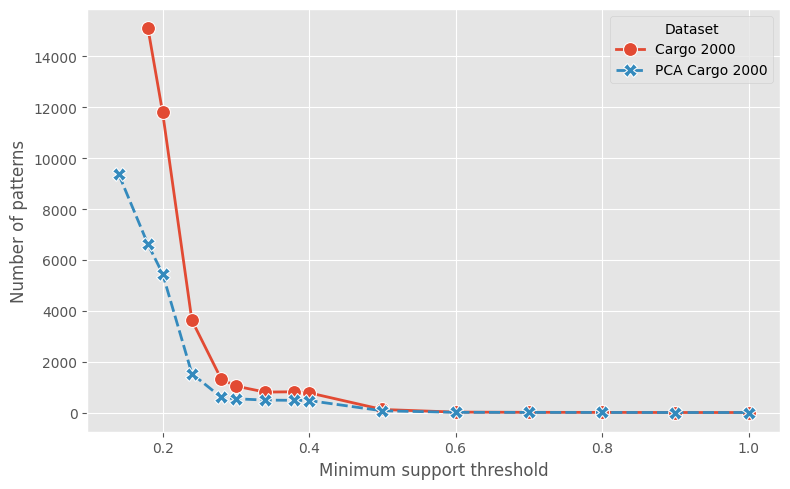

In [36]:
plot_number_pattern(df_cargo, "CARGO_support_vs_Nb_patters")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


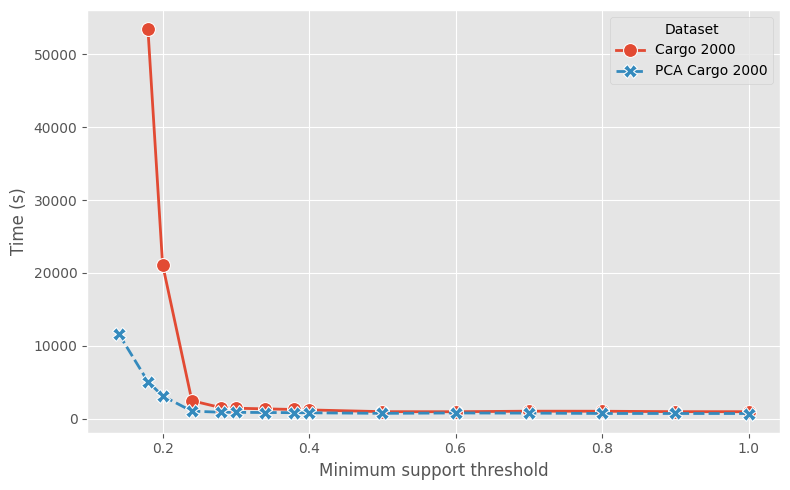

In [37]:
plot_time(df_cargo,"CARGO_Time_vs_support" )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


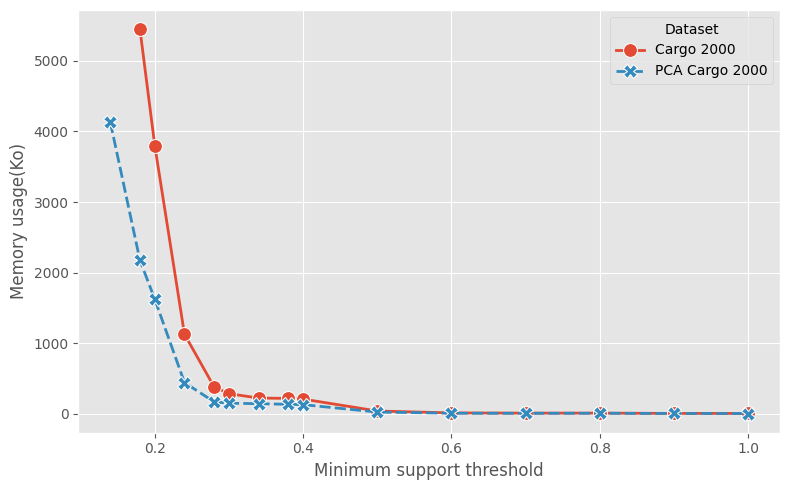

In [38]:
plot_memory(df_cargo,"CARGO_memory_vs_support" )

# Traitement du dataset Chickenpox

In [39]:
chicken = pd.read_excel("../data/serveur/Chickenpox.xlsx")
chicken_pca = pd.read_excel("../data/serveur/Chickenpox_PCA.xlsx")

In [40]:
chicken.head()

,Dataset,Support,Size,Temps d'exécution (s),Mémoire maximale (Ko),Titre variables,Supports motifs,Motifs detectés
0,./data/Clean/Chickenpox.csv,0.34,41522,172638.235327,31800.433594,"['1 : BUDAPEST', '2 : BARANYA', '3 : BACS', '4...","[0.34549679734668814, 0.35096079599355795, 0.3...","[{'7+', '4+', '17+', '6+', '1+', '18+'}, {'4+'..."
1,./data/Clean/Chickenpox.csv,0.38,22932,30516.866726,17329.897461,"['1 : BUDAPEST', '2 : BARANYA', '3 : BACS', '4...","[0.39770262021900116, 0.39309168192615146, 0.3...","[{'13+', '1+', '18+', '4+', '6+'}, {'1+', '18+..."
2,./data/Clean/Chickenpox.csv,0.40,16067,10529.315486,12136.811523,"['1 : BUDAPEST', '2 : BARANYA', '3 : BACS', '4...","[0.42511086107617974, 0.42213250380567874, 0.4...","[{'13+', '4+', '18+', '6+'}, {'16+', '4+', '18..."
3,./data/Clean/Chickenpox.csv,0.50,2280,144.305780,1281.600586,"['1 : BUDAPEST', '2 : BARANYA', '3 : BACS', '4...","[0.5417815724255595, 0.5384134548208941, 0.525...","[{'18+', '1+', '4+'}, {'18+', '1+', '16+'}, {'..."
4,./data/Clean/Chickenpox.csv,0.60,386,17.552623,104.405273,"['1 : BUDAPEST', '2 : BARANYA', '3 : BACS', '4...","[0.6669681793780013, 0.6727925224847588, 0.681...","[{'2+', '18+'}, {'2+', '20+'}, {'3+', '17+'}, ..."


In [41]:
df_chicken = pd.concat([chicken, chicken_pca], axis=0)  
df_chicken["Dataset"] = np.where(df_chicken["Dataset"] == './data/Clean/Chickenpox.csv','Chickenpox','PCA Chickenpox')
chicken["Motifs"] = transform_column(chicken["Motifs detectés"], transform_to_dict(chicken['Titre variables'].unique()))
chicken_pca["Motifs"] = transform_column(chicken_pca["Motifs detectés"], transform_to_dict(chicken_pca['Titre variables'].unique()))
chicken_valid = pd.DataFrame(count_common_Motifs(chicken, chicken_pca)).sort_values('Support')


In [42]:
chicken_valid

,Support,Pattern
0,0.34,367
1,0.38,503
4,0.40,247
3,0.50,287
2,0.60,92
5,0.70,44
6,0.80,0
7,0.90,1
8,1.00,1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


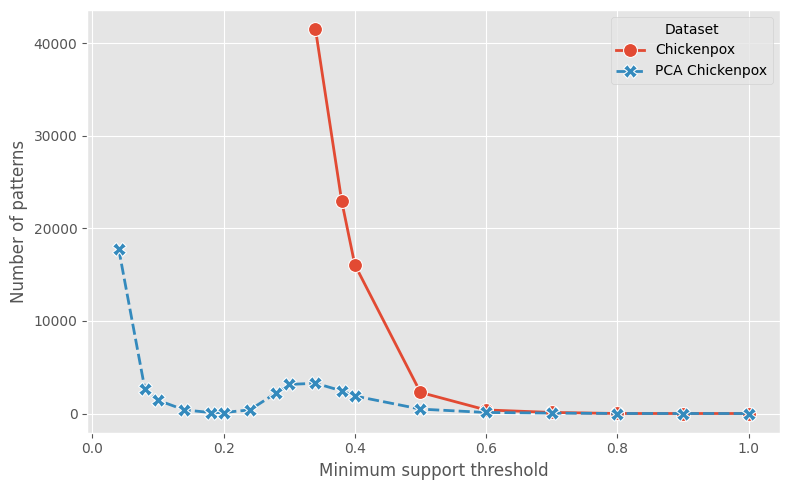

In [43]:
plot_number_pattern(df_chicken, "CHICKEN_support_vs_Nb_patters")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


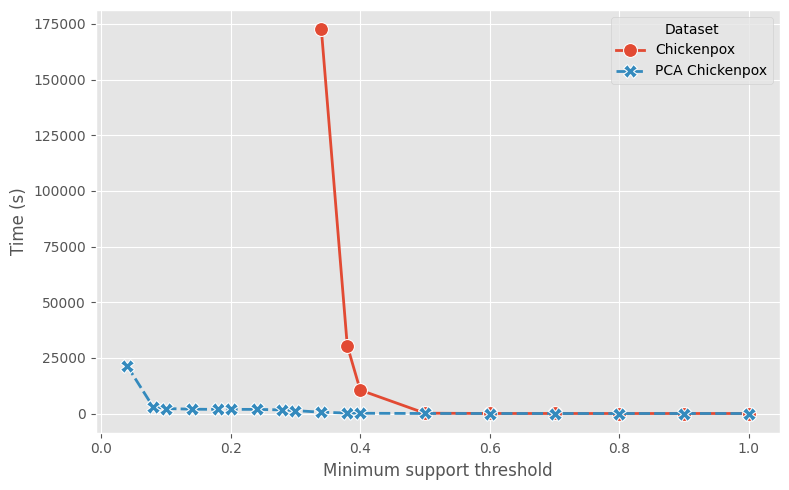

In [44]:
plot_time(df_chicken,"CHICKEN_Time_vs_support" )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


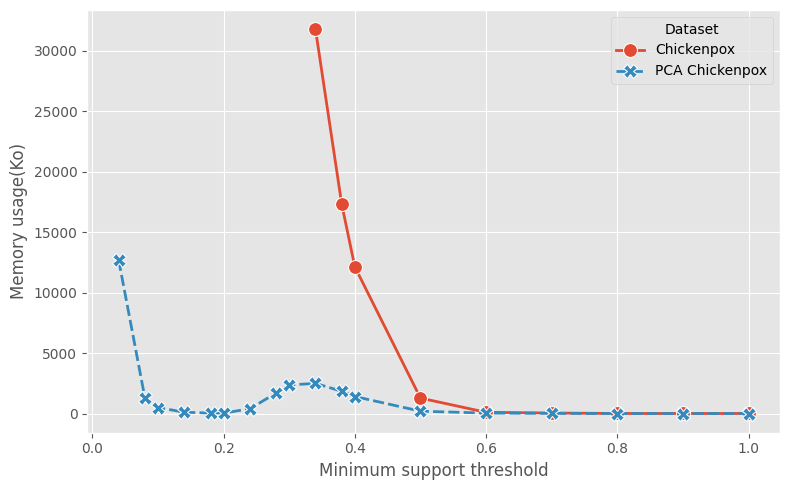

In [45]:
plot_memory(df_chicken,"chicken_memory_vs_support" )

In [75]:
combined_df.groupby('Dataset')['Size'].count()

Dataset
Air Quality.xlsx        17
Air Quality_PCA.xlsx    18
Cargo.xlsx              14
Cargo_PCA.xlsx          15
Chickenpox.xlsx          9
Chickenpox_PCA.xlsx     18
HCV.xlsx                20
HCV_PCA.xlsx            19
Name: Size, dtype: int64

In [76]:
all_df = pd.DataFrame()

In [78]:
all_df["Support"] = hcv["Support"]

In [89]:
hcv_valid.reset_index(drop=True, inplace=True)

In [90]:
all_df["Support"] = hcv["Support"]
all_df["Size HCV"] = hcv["Size"]
all_df["Size PCA HCV"] = hcv_pca["Size"]
all_df["HCV common"] = hcv_valid["Pattern"]
all_df["Size AQ"] = air["Size"]
all_df["Size PCA AQ"] = air_pca["Size"]
#all_df["AQ common"] = air_valid["Pattern"]
all_df["Size Cargo"] = cargo["Size"]
all_df["Size PCA Cargo"] = cargo_pca["Size"]
#all_df["Cargo common"] = cargo_valid["Pattern"]
all_df["Size Chicken"] = chicken["Size"]
all_df["Size PCA Chicken"] = chicken_pca["Size"]
#all_df["Chicken common"] = chicken_valid["Pattern"]


In [91]:
all_df

,Support,Size HCV,Size PCA HCV,Size AQ,Size PCA AQ,Size Cargo,Size PCA Cargo,Size Chicken,Size PCA Chicken,AQ common,HCV common
0,0.04,4716,582.0,309.0,149.0,15112.0,9378.0,41522.0,17808.0,14.0,75.0
1,0.08,2216,425.0,285.0,73.0,11807.0,6613.0,22932.0,2645.0,6.0,218.0
2,0.10,1525,347.0,250.0,58.0,3624.0,5461.0,16067.0,1428.0,4.0,231.0
3,0.14,813,218.0,218.0,35.0,1319.0,1527.0,2280.0,391.0,13.0,170.0
4,0.18,589,199.0,199.0,36.0,1039.0,598.0,386.0,105.0,7.0,159.0
5,0.20,496,211.0,174.0,44.0,803.0,541.0,117.0,107.0,11.0,138.0
6,0.24,272,164.0,167.0,51.0,815.0,488.0,1.0,390.0,11.0,83.0
7,0.28,176,102.0,143.0,51.0,775.0,479.0,0.0,2219.0,10.0,59.0
8,0.30,150,69.0,89.0,43.0,119.0,470.0,0.0,3141.0,9.0,49.0
9,0.34,120,55.0,74.0,29.0,16.0,67.0,NaN,3270.0,7.0,44.0


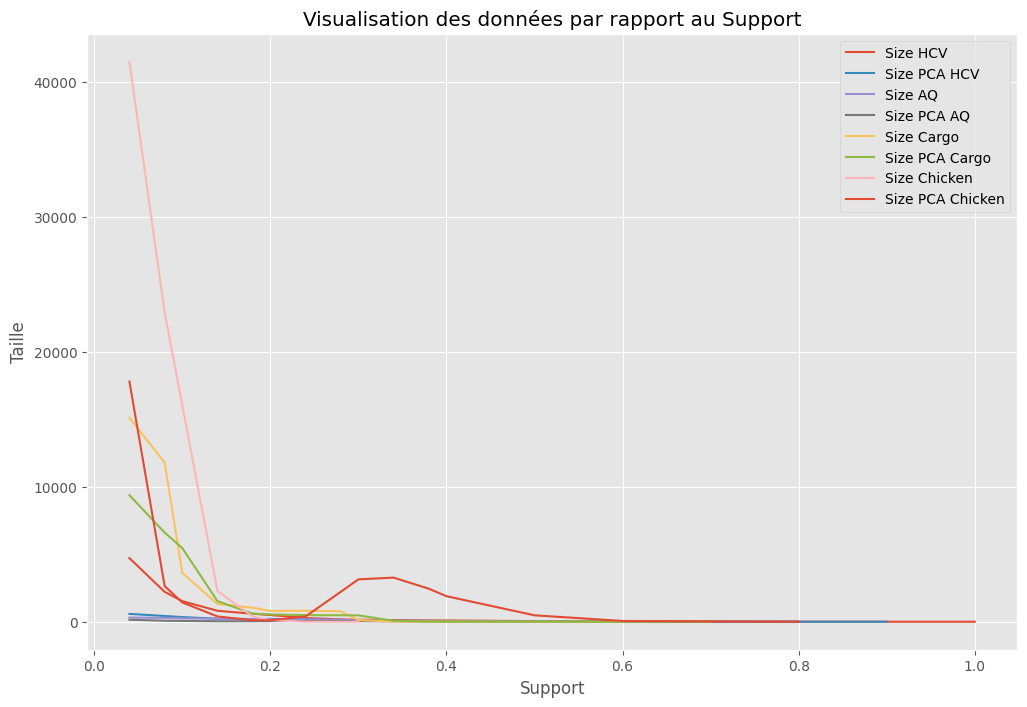

In [86]:
plt.figure(figsize=(12, 8))

for column in all_df.columns[1:]:
    sns.lineplot(data=all_df, x='Support',y= column, label=column)

# Ajouter des titres et des légendes
plt.title("Visualisation des données par rapport au Support")
plt.xlabel("Support")
plt.ylabel("Taille")
plt.legend()
plt.grid(True)

# Afficher le graphique
plt.show()